In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import latex, Matrix

In [152]:
import numpy as np

L = np.array([0.1,0.6,0.3])

n = 10
for i in range(10):
    print(L[1]," measurement:",i+1)
    for j in range(3):
        L[j] = L[j]**(i+2)
    L = L/np.sum(L) #normalize
    

0.6  measurement: 1
0.782608695652174  measurement: 2
0.9845946060017726  measurement: 3
0.9999999403953588  measurement: 4
1.0  measurement: 5
1.0  measurement: 6
1.0  measurement: 7
1.0  measurement: 8
1.0  measurement: 9
1.0  measurement: 10


In [153]:
"""
MAE 6760 Model Based Estimation
Cornell University
M Campbell

Homework #2
Problem #4: MMSE Estimation
for a time-varying output function
"""

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=8, suppress=True)

# =================================================
# Simulate the measurements
# =================================================
t = np.arange(0.1, 1.0 + 0.1, 0.1).reshape(-1, 1)
n = len(t)

x = np.array([[1.0],
              [1.0],
              [1.0]])

R_diag = np.array([0.001, 0.002, 0.005, 0.010, 0.008,
                   0.002, 0.010, 0.007, 0.020, 0.006])**2
R = np.diag(R_diag)

v = np.linalg.cholesky(R) @ np.random.randn(n, 1)

z = (
    x[0]
    + x[1] * np.sin(10 * t)
    + x[2] * np.exp(2 * t**2)
    + v
)

# =================================================
# Prior information
# =================================================
x0 = np.array([[1.01],
               [0.98],
               [0.99]])

P0 = np.eye(3) * 0.001

P0inv = np.linalg.inv(P0)


In [156]:
# =================================================
# Part (a): MMSE estimate
# =================================================


n = len(t)
A = np.zeros((3, 3))
B = np.zeros((3, 1))

for k, tk in enumerate(t):
    tk = tk[0] # weird type check because starter code saved t in a strange way
    H = np.array([[1, np.sin(10 * tk),np.exp(2 * tk**2)]])
    A += (1 / R_diag[k])*(H.T @ H)      # 3×3
    B += (1 / R_diag[k])*(H.T * z[k])   # 3×1


Bx = B + (P0inv @ x0)
Px = np.linalg.inv(A + P0inv)
    
xhat = Px @ Bx
print(xhat)

[[0.99787364]
 [1.00074421]
 [1.00092806]]


In [157]:
def MMSE_est(z,R_diag,P0):
    P0inv = np.linalg.inv(P0)
    A = np.zeros((3, 3))
    B = np.zeros((3, 1))

    for k, tk in enumerate(t):
        tk = tk[0] # weird type check because starter code saved t in a strange way
        H = np.array([[1, np.sin(10 * tk),np.exp(2 * tk**2)]])
        A += (1 / R_diag[k])*(H.T @ H)      # 3×3
        B += (1 / R_diag[k])*(H.T * z[k])   # 3×1


    Bx = B + (P0inv @ x0)
    Px = np.linalg.inv(A + P0inv)
        
    xhat = Px @ Bx
    return xhat, Px

MMSE_est(z,R_diag,P0)

(array([[0.99787364],
        [1.00074421],
        [1.00092806]]),
 array([[ 0.00000614, -0.00000413, -0.00000221],
        [-0.00000413,  0.00000402,  0.00000123],
        [-0.00000221,  0.00000123,  0.00000108]]))

In [35]:
Px

array([[ 0.00066668, -0.00033332, -0.00033332],
       [-0.00033332,  0.00066668, -0.00033332],
       [-0.00033332, -0.00033332,  0.00066668]])

In [36]:
Bx

array([[4832564.97316326, 2900474.87121868, 7552812.21414985]])

In [158]:
alphai = np.array([10**-3, 10**-2,10**-1,1,10,10**2,10**3])

xi = np.zeros((3,7))
sigi = []

for i,alpha in enumerate(alphai):

    R_diag_new = alpha * R_diag
    R = np.diag(R_diag_new)

    v = np.linalg.cholesky(R) @ np.random.randn(n, 1)

    z = (
        x[0]
        + x[1] * np.sin(10 * t)
        + x[2] * np.exp(2 * t**2)
        + v
    )
    xhat, Px = MMSE_est(z,R_diag_new,P0)
    xi[:,i] = xhat.T
    sigi.append(Px)

In [184]:
plt.rcParams.update({'font.size': 17})

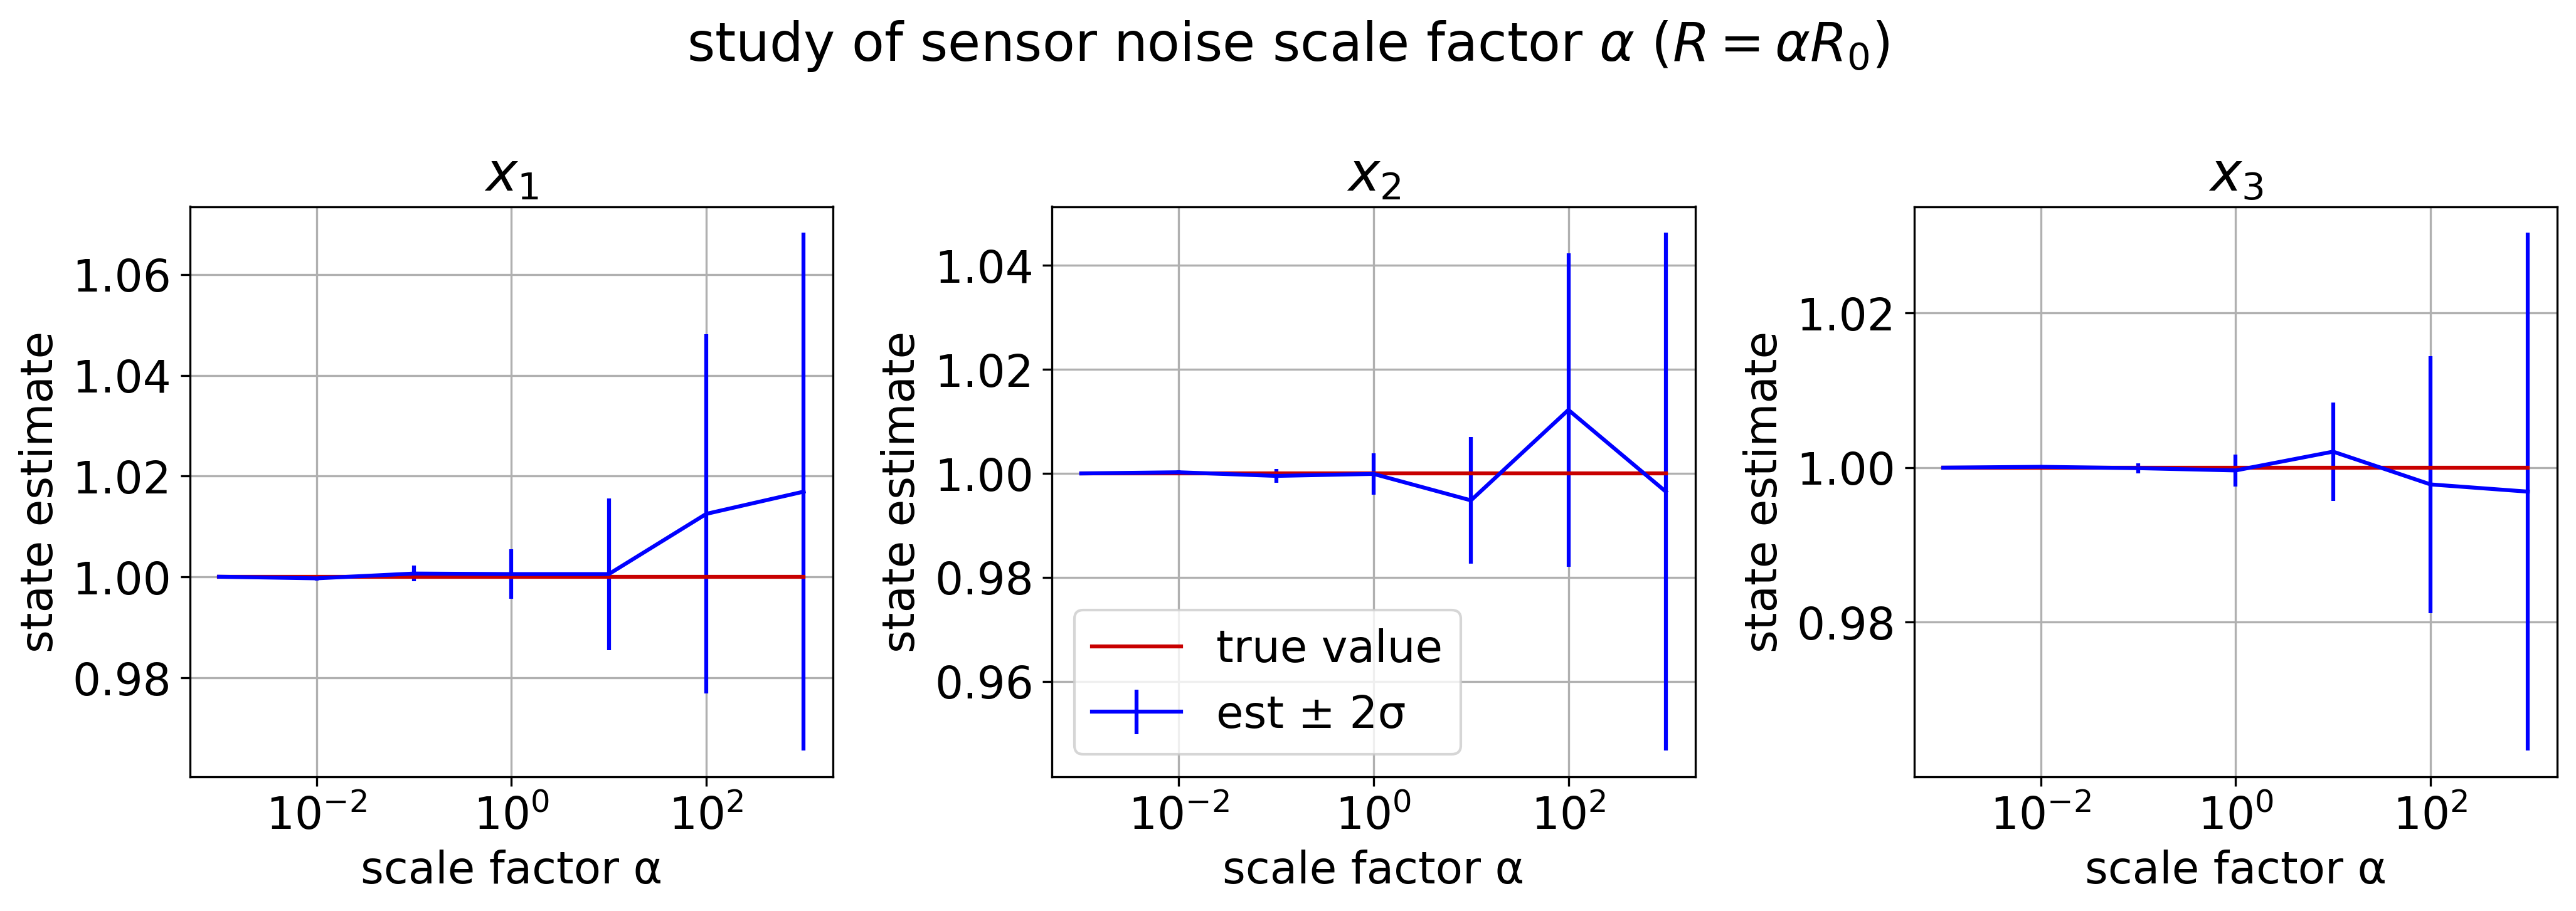

In [185]:

alphai = np.array([1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3])

ni = len(alphai)

xi = np.zeros((3, ni))
sigi = np.zeros((3, ni))

for i, alpha in enumerate(alphai):

    # Scale measurement covariance correctly
    R_diag_new = alpha * R_diag
    R = np.diag(R_diag_new)

    v = np.linalg.cholesky(R) @ np.random.randn(n, 1)

    z = (
        x[0]
        + x[1] * np.sin(10 * t)
        + x[2] * np.exp(2 * t**2)
        + v
    )

    xhat, Px = MMSE_est(z, R_diag_new,P0)
    xi[:, i] = xhat.flatten()
    sigi[:, i] = np.sqrt(np.diag(Px))
# =================================================
# Part (b): Varying sensor noise
# =================================================

# plotting routine for error bars, assuming 3x7 xi and sigi


# Plot results
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True,dpi = 300)
true_val = np.ones(ni)

for i in range(3):
    axes[i].errorbar(alphai, xi[i, :], 2 * sigi[i, :], fmt='b', label = 'est ± 2σ')
    axes[i].semilogx(alphai, true_val, color=(200/255, 0, 0),label = 'true value')
    axes[i].set_xscale('log')
    axes[i].grid(True)
    axes[i].set_xlabel('scale factor α')
    axes[i].set_ylabel('state estimate')
    axes[i].set_title(r"$x_" + str(i+1) + "$")

axes[1].legend( loc='lower left')
fig.suptitle(r'study of sensor noise scale factor $\alpha$ ($R=\alpha R_0$)')

plt.tight_layout()



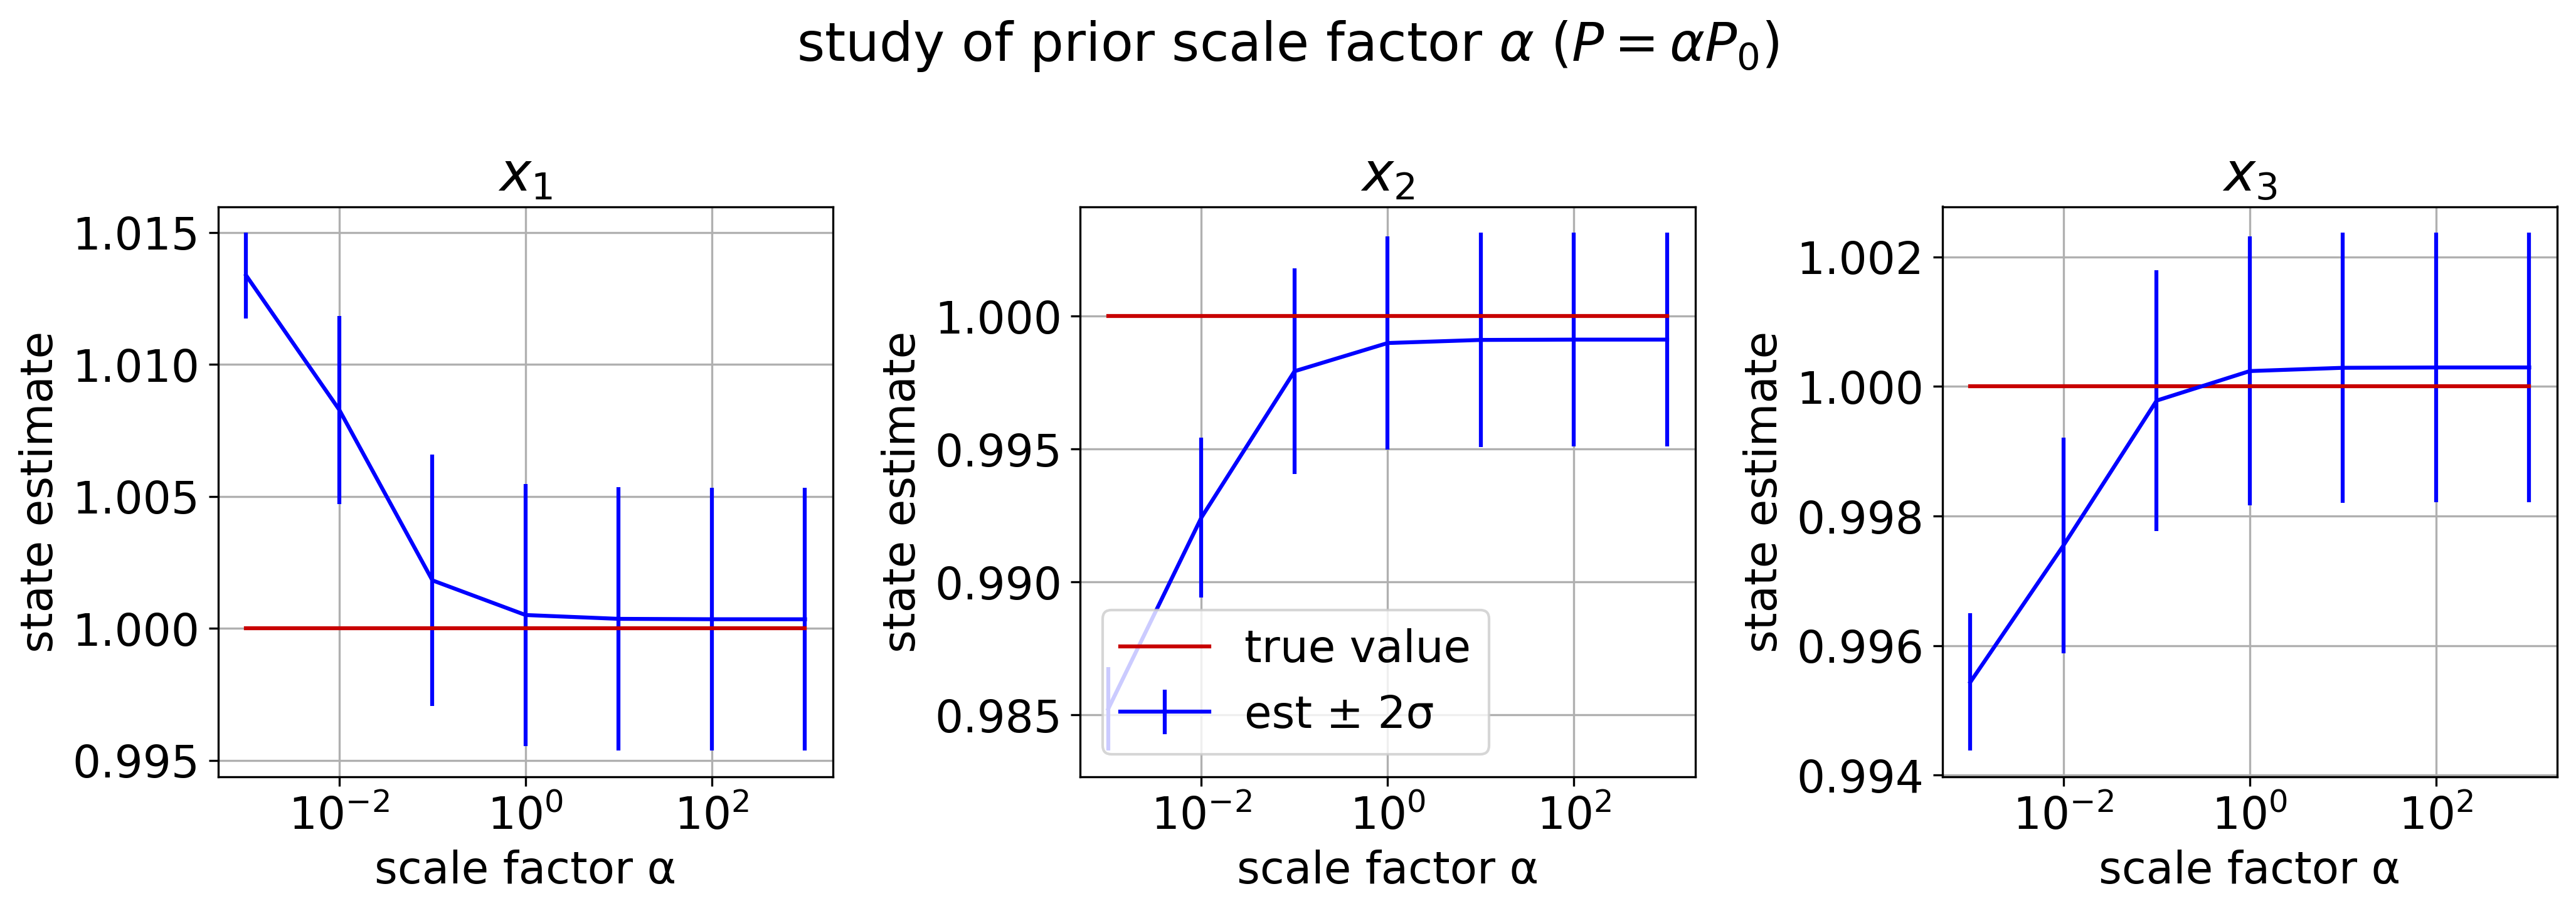

In [188]:
# =================================================
# Part (c): Varying prior
# =================================================

# plotting routine for error bars, assuming 3x7 xi and sigi

# Plot results


alphai = np.array([1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3])

ni = len(alphai)

xi = np.zeros((3, ni))
sigi = np.zeros((3, ni))

R_diag = np.array([0.001, 0.002, 0.005, 0.010, 0.008,
                   0.002, 0.010, 0.007, 0.020, 0.006])**2
R = np.diag(R_diag)

v = np.linalg.cholesky(R) @ np.random.randn(n, 1)

z = (
    x[0]
    + x[1] * np.sin(10 * t)
    + x[2] * np.exp(2 * t**2)
    + v
)

for i, alpha in enumerate(alphai):
    P0new = alpha * P0

    xhat, Px = MMSE_est(z, R_diag,P0new)
    xi[:, i] = xhat.flatten()
    sigi[:, i] = np.sqrt(np.diag(Px))



fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True,dpi = 300)

for i in range(3):
    axes[i].errorbar(alphai, xi[i, :], 2 * sigi[i, :], fmt='b', label ='est ± 2σ')
    axes[i].semilogx(alphai, true_val, color=(200/255, 0, 0),label = 'true value')
    axes[i].set_xscale('log')
    axes[i].grid(True)
    axes[i].set_xlabel('scale factor α')
    axes[i].set_ylabel('state estimate')
    axes[i].set_title(r"$x_" + str(i+1) + "$")

axes[1].legend(loc='lower left')
fig.suptitle(r'study of prior scale factor $\alpha$ ($P=\alpha P_0$)')
plt.tight_layout()
plt.show()

## Problem 5

In [ ]:
"""
MAE 6760 Model Based Estimation
Cornell University
M Campbell

Homework #2
Problem #5: Nonlinear Least Squares
for multi-sensor range localization problem
"""

import numpy as np

np.set_printoptions(precision=5, suppress=True)
np.random.seed(10)

# =================================================
# Problem setup: beacons and measurements
# =================================================
bA = np.array([[-10.0], [100.0]])
bB = np.array([[490.0], [20.0]])
bC = np.array([[500.0], [40.0]])
beacons = np.hstack((bA, bB, bC))

xtrue = np.array([[-5.0], [2.0]])

# Perfect ranges
RA = np.linalg.norm(bA - xtrue)
RB = np.linalg.norm(bB - xtrue)
RC = np.linalg.norm(bC - xtrue)

n = 10  # number of measurements

# =================================================
# Part (a): three beacons (A,B,C)
# =================================================
Rpart_a = np.diag([10.0, 10.0, 10.0])
v_a = np.linalg.cholesky(Rpart_a) @ np.random.randn(3, n)
z_a = np.tile(np.array([[RA], [RB], [RC]]), (1, n)) + v_a

R = np.diag([10,10,10])
Rinv = np.linalg.inv(R)

In [ ]:
x = np.array([[0.0],[0.0]])

maxiter = 100
iter = 0
blst = np.asarray([bA,bB,bC])
stop = False
thresh = 1e-9
while iter < maxiter and stop == False:

    A = np.zeros((2,2))
    g = np.zeros((2,1))
    
    for k in range(n):
        H = np.zeros((3,2))
        h = np.zeros((3,1))

        for i in range(3):
            r = np.linalg.norm(blst[i]-x)
            h[i][0] = r
            for j in range(2):
                H[i,j] = -(blst[i,j][0]- x[j,0])/r
                
        
        diff = z_a[:,k].reshape(3,1) - h

        A += H.T @ Rinv @ H
        g += H.T @ Rinv @ diff

    deltax =  np.linalg.inv(A) @ g
    if np.linalg.norm(deltax) < thresh:
        stop = True
    x += deltax

    iter += 1

print(x)

[[-5.83262]
 [ 1.76095]] 5


In [261]:
# =================================================
# Part (b): two beacons (A,B) and (B,C)
# =================================================
# (A,B)
ii = [0, 1]
Rpart_b1 = Rpart_a[np.ix_(ii, ii)]
z_b1 = z_a[ii, :]


x = np.array([[0.0],[0.0]])

maxiter = 100
iter = 0
blst = np.asarray([bA,bB])
stop = False
thresh = 1e-9
while iter < maxiter and stop == False:

    A = np.zeros((2,2))
    g = np.zeros((2,1))
    
    for k in range(n):
        H = np.zeros((2,2))
        h = np.zeros((2,1))

        for i in range(2):
            r = np.linalg.norm(blst[i]-x)
            h[i][0] = r
            for j in range(2):
                H[i,j] = -(blst[i,j][0]- x[j,0])/r
                
        
        diff = z_b1[:,k].reshape(2,1) - h

        A += H.T @ Rinv @ H
        g += H.T @ Rinv @ diff

    deltax =  np.linalg.inv(A) @ g
    if np.linalg.norm(deltax) < thresh:
        stop = True
    x += deltax

    iter += 1

print(x)





ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)

In [ ]:


# (B,C)
ii = [1, 2]
Rpart_b2 = Rpart_a[np.ix_(ii, ii)]
z_b2 = z_a[ii, :]



In [ ]:
# =================================================
# Part (c): perfect linearization
# =================================================




In [ ]:
# =================================================
# Part (d): correlated noise
# =================================================
Rpart_d = np.array([[10, 0, 0],
                    [0, 10, 9],
                    [0, 9, 10]], dtype=float)

v_d = np.linalg.cholesky(Rpart_d) @ np.random.randn(3, n)
z_d = np.tile(np.array([[RA], [RB], [RC]]), (1, n)) + v_d

